##  H-bond analysis

This notebook is a H-bond analysis between residues of a protein along a molecular dynamics trajectory. This is done using the `MDAnalysis` library in Python for the infamous p53 manuscript.

In [15]:
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis
from shutil import which
import MDAnalysis as mda
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import glob
import os 

def analyze_residue_hbonds(topology_file, 
                           trajectory_file, 
                           first_selection, 
                           second_selection, 
                           d_a_cutoff=3.0, 
                           d_h_a_angle_cutoff=150.0,
                           donors_sel = None,
                           hydrogens_sel = None,
                           acceptors_sel = None,
                           remove_pbc=False
                            
    ):
    """
    Calculates hydrogen bonds between two specific residues in a trajectory.

    Parameters:
    -----------
    topology_file : str
        Path to the .parm7 file.
    trajectory_file : str
        Path to the .dcd file.
    first_selection : str
        The selection for the first group of atoms.
    second_selection : str
        The selection for the second group of atoms.
    d_a_cutoff : float
        Distance cutoff in Angstroms between donor and acceptor (default 3.0).
    d_h_a_angle_cutoff : float
        Angle cutoff in degrees for donor-hydrogen-acceptor (default 150.0).
    donors_sel : str or None
        Atom selection string for donors (default None).
    hydrogens_sel : str or None
        Atom selection string for hydrogens (default None).
    acceptors_sel : str or None
        Atom selection string for acceptors (default None).
    remove_pbc : bool
        If True, disables periodic boundary conditions by setting u.dimensions to None.

    Returns:
    --------
    pd.DataFrame
        A DataFrame containing the frames, donor, acceptor, and geometry details
        of every hydrogen bond found.
    int
        Total number of frames in the trajectory.
    """
    
    print(f"Loading Universe: {os.path.basename(topology_file)} | {os.path.basename(trajectory_file)}")
    # 1. Load the Universe
    u = mda.Universe(topology_file, trajectory_file)

    # If the box is tiny or incorrect, we remove it. This forces MDAnalysis
    # to use a distance calculation that doesn't worry about the box edges.
    if remove_pbc:
        print("Disabling Periodic Boundary Conditions (setting u.dimensions to None).")
        u.dimensions = None
        
    # 2. Define Atom Selections
    # Select atoms to find residue name
    atoms_sel1 = u.select_atoms(first_selection)
    atoms_sel2 = u.select_atoms(second_selection)
    sel1_residues = set(atoms_sel1.residues.resids)
    sel2_residues = set(atoms_sel2.residues.resids)
    print(f"First selection residues: {sel1_residues}")
    print(f"Second selection residues: {sel2_residues}")
    
    # Check the selections contain either donor and hydrogen or acceptor atoms
    if donors_sel is not None and hydrogens_sel is not None:
        # Check the first selection has donors and hydrogens
        donors1 = u.select_atoms(f"({first_selection}) and ({donors_sel})")
        hydrogens1 = u.select_atoms(f"({first_selection}) and ({hydrogens_sel})")
        # Check the second selection has donors and hydrogens
        donors2 = u.select_atoms(f"({second_selection}) and ({donors_sel})")
        hydrogens2 = u.select_atoms(f"({second_selection}) and ({hydrogens_sel})")
        if len(donors1) == 0 or len(hydrogens1) == 0:
            if len(donors2) == 0 or len(hydrogens2) == 0:
                raise ValueError("Neither selection contains donor and hydrogen atoms.")
            else:
                print(f"Donor {donors2} and Hydrogen {hydrogens2} found in second selection ({second_selection})")
        else:
            print(f"Donor {donors1} and Hydrogen {hydrogens1} found in first selection ({first_selection})")
            
    if acceptors_sel is not None:
        # Check the first selection has acceptors
        acceptors1 = u.select_atoms(f"({first_selection}) and ({acceptors_sel})")
        # Check the second selection has acceptors
        acceptors2 = u.select_atoms(f"({second_selection}) and ({acceptors_sel})")
        if len(acceptors1) == 0:
            if len(acceptors2) == 0:
                raise ValueError("Neither selection contains acceptor atoms.")
            else:
                print(f"Acceptor {acceptors2} found in second selection ({second_selection})")
        else:
            print(f"Acceptor {acceptors1} found in first selection ({first_selection})")

    
    print(f"Analyzing H-bonds between '{first_selection}' and '{second_selection}'...")

    # 3. Initialize Hydrogen Bond Analysis
    # 'between' ensures we only look for bonds connecting first_selection and second_selection
    hbonds = HydrogenBondAnalysis(
        universe=u,
        between=[first_selection, second_selection],
        d_a_cutoff=d_a_cutoff,                  # Distance Donor-Acceptor
        d_h_a_angle_cutoff=d_h_a_angle_cutoff,  # Angle Donor-Hydrogen-Acceptor
        donors_sel=donors_sel,
        hydrogens_sel=hydrogens_sel,
        acceptors_sel=acceptors_sel
    )

    # 4. Run the analysis
    # verbose=True will show a progress bar
    hbonds.run(verbose=True)

    # 5. Process Results
    # The raw results are in hbonds.results.hbonds. 
    # We convert this to a readable DataFrame.
    columns = ["frame", "donor_idx", "hydrogen_idx", "acceptor_idx", "distance", "angle"]
    df = pd.DataFrame(hbonds.results.hbonds, columns=columns)

    # Map atom indices back to atom names and residue names for better readability
    # MDAnalysis uses 0-based indexing internally
    def get_atom_info(idx):
        atom = u.atoms[int(idx)]
        return f"{atom.resname}{atom.resid}:{atom.name}"

    if not df.empty:
        df['donor_label'] = df['donor_idx'].apply(get_atom_info)
        df['acceptor_label'] = df['acceptor_idx'].apply(get_atom_info)
        print(f"Analysis Complete. Found {len(df)} hydrogen bond occurrences.")
    else:
        print("Analysis Complete. No hydrogen bonds found.")

    return df, u.trajectory.n_frames

def plot_hbond_timeline(df, total_frames, window=10, dt=1.0, title="Hydrogen Bond Timeline"):
    """
    Plots the existence and occupancy of hydrogen bonds over the trajectory.

    Parameters:
    -----------
    df : pd.DataFrame
        The output DataFrame from the previous analysis function.
    total_frames : int
        The total number of frames in the original trajectory 
        (needed to account for frames where NO bond exists).
    window : int
        The size of the rolling window for the average occupancy line.
    dt : float
        Time step per frame in ns (e.g., 0.02 ns) to convert X-axis to time. 
        Set to 1.0 to plot by Frame number.
    title : str
        Title of the plot.
    """
    
    # 1. Create a binary timeline (0 = No Bond, 1 = Bond Exists)
    # We create an array of Zeros representing the full simulation
    timeline = np.zeros(total_frames)
    
    if not df.empty:
        # Get unique frames where a bond existed
        # We cast to int because frame indices are integers
        active_frames = df['frame'].unique().astype(int)
        
        # Determine valid frames (filter out frames out of range if necessary)
        valid_frames = active_frames[active_frames < total_frames]
        
        # Set those specific frames to 1
        timeline[valid_frames] = 1

    # 2. Create the Time Axis
    time_axis = np.arange(total_frames) * dt
    xlabel_text = "Time (ns)" if dt != 1.0 else "Frame"

    # 3. Calculate Rolling Occupancy (Percentage)
    # This creates a pandas Series to use the powerful .rolling() method
    ts_series = pd.Series(timeline)
    # We calculate the mean over the window and multiply by 100 for percentage
    occupancy_smooth = ts_series.rolling(window=window, center=True).mean() * 100

    # 4. Calculate Global Occupancy
    global_occ = (np.sum(timeline) / total_frames) * 100

    # --- PLOTTING ---
    plt.figure(figsize=(10, 5))

    # Plot A: The raw binary data (The "Barcode")
    # We fill the area to make it look like a barcode scanner
    plt.fill_between(time_axis, 0, timeline * 100, 
                     color='skyblue', alpha=0.3, label='Instantaneous (On/Off)')

    # Plot B: The Running Average (The thick line)
    plt.plot(time_axis, occupancy_smooth, 
             color='darkblue', linewidth=2, label=f'Rolling Avg ({window} frames)')

    # Formatting
    plt.title(f"{title}\nGlobal Occupancy: {global_occ:.2f}%")
    plt.ylabel("Occupancy (%)")
    plt.xlabel(xlabel_text)
    plt.ylim(0, 105)  # 0 to 100%
    plt.legend(loc="upper right")
    plt.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()

def plot_multibond_barcode_pub(hbond_dict, total_frames, dt=1.0, title="H-Bond Interactions", font_size=12):
    """
    Plots a publication-ready barcode plot for hydrogen bond interactions.
    """
    
    # --- LATEX & FONT SETUP ---
    # Check if latex is available on the system
    if which("latex") and which("dvipng"):
        plt.rcParams['text.usetex'] = True
        plt.rcParams['font.family'] = 'serif'
    else:
        # Fallback if LaTeX is not installed
        plt.rcParams['text.usetex'] = False
        plt.rcParams['font.family'] = 'serif' # Matplotlib serif approximation
        print("Warning: LaTeX not found. Using standard Matplotlib serif font.")

    font = {'weight' : 'normal', 'size' : font_size}
    plt.rc('font', **font)

    # --- DYNAMIC HEIGHT CALCULATION ---
    # We allow 0.5 inches per bond, plus 1.5 inches for the title/x-axis
    # This ensures the bars always look the same thickness, regardless of how many there are.
    n_bonds = len(hbond_dict)
    calculated_height = max(3.0, n_bonds * 0.5 + 1.5) 

    # 3. Create Figure with Dynamic Height
    fig, ax = plt.subplots(figsize=(12, calculated_height), facecolor='white')
    ax.set_facecolor('white')
    
    event_data = []
    labels = []
    colors = []
    
    # Use tab10 (high contrast) or distinct colors
    cmap = plt.get_cmap('tab10') 
    
    # Iterate in reverse for top-down plotting
    for i, (bond_name, df) in enumerate(reversed(hbond_dict.items())):
        
        # Clean bond name for LaTeX (underscores cause errors in LaTeX)
        clean_name = bond_name.replace("_", "-") 

        if not df.empty and 'frame' in df.columns:
            frames = df['frame'].values * dt
            event_data.append(frames)
            
            occupancy = (df['frame'].nunique() / total_frames) * 100
            
            # CRITICAL: Escape the % sign for LaTeX (Use \%)
            if plt.rcParams['text.usetex']:
                label_text = f"{clean_name} ({occupancy:.1f}\%)"
            else:
                label_text = f"{clean_name} ({occupancy:.1f}%)"
            
            labels.append(label_text)
            colors.append(cmap(i % 10))
        else:
            event_data.append([])
            if plt.rcParams['text.usetex']:
                labels.append(f"{clean_name} (0.0\%)")
            else:
                labels.append(f"{clean_name} (0.0%)")
            colors.append('gray')

    # --- PLOTTING ---
    ax.eventplot(event_data, 
                 linewidths=0.2,
                 lineoffsets=np.arange(len(event_data)), 
                 linelengths=1,
                 colors=colors,
                 alpha=1.0)

    # --- FORMATTING ---
    # Set Y-axis labels
    ax.set_yticks(np.arange(len(labels)))
    ax.set_yticklabels(labels, fontsize=font_size)
    
    # --- TIGHTEN Y-AXIS ---
    # This removes the extra whitespace above and below the bars
    # We set limits from -0.5 to N-0.5
    ax.set_ylim(-0.6, len(labels) - 0.4)
    
    # Labels and Title
    ax.set_xlabel("Time (ns)" if dt != 1.0 else "Frame", fontsize=font_size)
    ax.set_title(title, fontsize=font_size + 2)
    
    # Spines (Publication style: typically keeping bottom and left)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False) # Hiding the vertical line, keeping ticks
    ax.spines['bottom'].set_linewidth(1.2) # Make bottom axis distinct
    
    # Tick params
    ax.tick_params(axis='y', length=0) # Remove tick lines on Y, keep text
    ax.tick_params(axis='x', width=1.2)
    
    # X-axis limits
    ax.set_xlim(0, total_frames * dt)
    
    # Grid (Subtle gray for white background)
    ax.grid(axis='x', color='gray', linestyle=':', alpha=0.3)

    plt.tight_layout()
    plt.show()

In [2]:
# Set up data
data_folder = "/shared/work/pnavarro/repos/deep_cartograph/examples/P53/Data"
traj_extension = "pdb"
trajectories_folder = f"{data_folder}/trajectories_{traj_extension}"
topology_path = f"{data_folder}/p53.pdb"
trajectory_paths = glob.glob(f"{trajectories_folder}/*.{traj_extension}")

In [3]:
# Look for H-bonds between S116 and R282
results = {}
for trajectory in trajectory_paths:
    traj_name = os.path.basename(trajectory)
    resulting_df, num_frames = analyze_residue_hbonds(
        topology_file=topology_path, 
        trajectory_file=trajectory, 
        first_selection="resid 189",    # Donor - ARG
        second_selection="resid 23",    # Acceptor - SER
        d_a_cutoff=3.0, 
        d_h_a_angle_cutoff=120.0,
        donors_sel="name NE or name NH1 or name NH2",
        hydrogens_sel="name HE or name HH11 or name HH12 or name HH21 or name HH22",
        acceptors_sel="name O or name OG"
    )
    results[traj_name] = {
        "ARG189-SER23": resulting_df,
        "num_frames": num_frames
    }

Loading Universe: p53.pdb | 1tsr.pdb


/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


First selection residues: {189}
Second selection residues: {23}
Donor <AtomGroup [<Atom 2902: NE of type N of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2905: NH1 of type N of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2908: NH2 of type N of resname ARG, resid 189 and segid SYSTEM and altLoc >]> and Hydrogen <AtomGroup [<Atom 2903: HE of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2906: HH11 of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2907: HH12 of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2909: HH21 of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2910: HH22 of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >]> found in first selection (resid 189)
Acceptor <AtomGroup [<Atom 2912: O of type O of resname ARG, resid 189 and segid SYSTEM and altLoc >]> found in first selection (resid 189)
Analyzing H-bonds between 'resid 189' and 'resid

  0%|          | 0/9998 [00:00<?, ?it/s]

/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/analysis/base.py:542: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time
/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py:775: UserWarning: No hydrogen bonds were found given angle of 120.0 between Donor, name NE or name NH1 or name NH2, and Acceptor, name O or name OG.
  warnings.warn(


...

/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


First selection residues: {189}
Second selection residues: {23}
Donor <AtomGroup [<Atom 2902: NE of type N of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2905: NH1 of type N of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2908: NH2 of type N of resname ARG, resid 189 and segid SYSTEM and altLoc >]> and Hydrogen <AtomGroup [<Atom 2903: HE of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2906: HH11 of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2907: HH12 of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2909: HH21 of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2910: HH22 of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >]> found in first selection (resid 189)
Acceptor <AtomGroup [<Atom 2912: O of type O of resname ARG, resid 189 and segid SYSTEM and altLoc >]> found in first selection (resid 189)
Analyzing H-bonds between 'resid 189' and 'resid

  0%|          | 0/9998 [00:00<?, ?it/s]

/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/analysis/base.py:542: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time
/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py:775: UserWarning: No hydrogen bonds were found given angle of 120.0 between Donor, name NE or name NH1 or name NH2, and Acceptor, name O or name OG.
  warnings.warn(


Analysis Complete. Found 10 hydrogen bond occurrences.


In [4]:
# Look for H-bonds between T125 and R282
for trajectory in trajectory_paths:
    traj_name = os.path.basename(trajectory)
    resulting_df, num_frames = analyze_residue_hbonds(
        topology_file=topology_path, 
        trajectory_file=trajectory, 
        first_selection="resid 189",    # Donor - ARG
        second_selection="resid 32",    # Acceptor - THR
        d_a_cutoff=3.0, 
        d_h_a_angle_cutoff=120.0,
        donors_sel="name NE or name NH1 or name NH2",
        hydrogens_sel="name HE or name HH11 or name HH12 or name HH21 or name HH22",
        acceptors_sel="name O or name OG1"
    )
    results[traj_name].update({
        "ARG189-THR32": resulting_df,
    })
    results[traj_name]["num_frames"] = num_frames   

Loading Universe: p53.pdb | 1tsr.pdb


/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


First selection residues: {189}
Second selection residues: {32}
Donor <AtomGroup [<Atom 2902: NE of type N of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2905: NH1 of type N of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2908: NH2 of type N of resname ARG, resid 189 and segid SYSTEM and altLoc >]> and Hydrogen <AtomGroup [<Atom 2903: HE of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2906: HH11 of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2907: HH12 of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2909: HH21 of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2910: HH22 of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >]> found in first selection (resid 189)
Acceptor <AtomGroup [<Atom 2912: O of type O of resname ARG, resid 189 and segid SYSTEM and altLoc >]> found in first selection (resid 189)
Analyzing H-bonds between 'resid 189' and 'resid

  0%|          | 0/9998 [00:00<?, ?it/s]

/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/analysis/base.py:542: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time
/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py:775: UserWarning: No hydrogen bonds were found given angle of 120.0 between Donor, name NE or name NH1 or name NH2, and Acceptor, name O or name OG1.
  warnings.warn(


...

/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


First selection residues: {189}
Second selection residues: {32}
Donor <AtomGroup [<Atom 2902: NE of type N of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2905: NH1 of type N of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2908: NH2 of type N of resname ARG, resid 189 and segid SYSTEM and altLoc >]> and Hydrogen <AtomGroup [<Atom 2903: HE of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2906: HH11 of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2907: HH12 of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2909: HH21 of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >, <Atom 2910: HH22 of type H of resname ARG, resid 189 and segid SYSTEM and altLoc >]> found in first selection (resid 189)
Acceptor <AtomGroup [<Atom 2912: O of type O of resname ARG, resid 189 and segid SYSTEM and altLoc >]> found in first selection (resid 189)
Analyzing H-bonds between 'resid 189' and 'resid

  0%|          | 0/9998 [00:00<?, ?it/s]

/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/analysis/base.py:542: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time
/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py:775: UserWarning: No hydrogen bonds were found given angle of 120.0 between Donor, name NE or name NH1 or name NH2, and Acceptor, name O or name OG1.
  warnings.warn(
/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py:743: UserWarning: No hydrogen bonds were found given d-a cutoff of 3.0 between Donor, name NE or name NH1 or name NH2, and Acceptor, name O or name OG1.
  warnings.warn(


Analysis Complete. Found 6066 hydrogen bond occurrences.


In [5]:
# Look for H-bonds between T125 and G117
for trajectory in trajectory_paths:
    traj_name = os.path.basename(trajectory)
    resulting_df, num_frames = analyze_residue_hbonds(
        topology_file=topology_path, 
        trajectory_file=trajectory, 
        first_selection="resid 32",    # Donor - THR
        second_selection="resid 24",    # Acceptor - GLY
        d_a_cutoff=3.0, 
        d_h_a_angle_cutoff=120.0,
        donors_sel="name OG1",
        hydrogens_sel="name HG1",
        acceptors_sel="name O"
    )
    results[traj_name].update({
        "THR32-GLY24": resulting_df,
    })
    results[traj_name]["num_frames"] = num_frames  

Loading Universe: p53.pdb | 1tsr.pdb


/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


First selection residues: {32}
Second selection residues: {24}
Donor <AtomGroup [<Atom 466: OG1 of type O of resname THR, resid 32 and segid SYSTEM and altLoc >]> and Hydrogen <AtomGroup [<Atom 467: HG1 of type H of resname THR, resid 32 and segid SYSTEM and altLoc >]> found in first selection (resid 32)
Acceptor <AtomGroup [<Atom 469: O of type O of resname THR, resid 32 and segid SYSTEM and altLoc >]> found in first selection (resid 32)
Analyzing H-bonds between 'resid 32' and 'resid 24'...


  0%|          | 0/9998 [00:00<?, ?it/s]

/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/analysis/base.py:542: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time
/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py:775: UserWarning: No hydrogen bonds were found given angle of 120.0 between Donor, name OG1, and Acceptor, name O.
  warnings.warn(
/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py:743: UserWarning: No hydrogen bonds were found given d-a cutoff of 3.0 between Donor, name OG1, and Acceptor, name O.
  warnings.warn(


...

/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/topology/PDBParser.py:350: UserWarning: Element information is missing, elements attribute will not be populated. If needed these can be guessed using universe.guess_TopologyAttrs(context='default', to_guess=['elements']).
  warnings.warn("Element information is missing, elements attribute "


First selection residues: {32}
Second selection residues: {24}
Donor <AtomGroup [<Atom 466: OG1 of type O of resname THR, resid 32 and segid SYSTEM and altLoc >]> and Hydrogen <AtomGroup [<Atom 467: HG1 of type H of resname THR, resid 32 and segid SYSTEM and altLoc >]> found in first selection (resid 32)
Acceptor <AtomGroup [<Atom 469: O of type O of resname THR, resid 32 and segid SYSTEM and altLoc >]> found in first selection (resid 32)
Analyzing H-bonds between 'resid 32' and 'resid 24'...


  0%|          | 0/9998 [00:00<?, ?it/s]

/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/analysis/base.py:542: UserWarning: Reader has no dt information, set to 1.0 ps
  self.times[idx] = ts.time
/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py:775: UserWarning: No hydrogen bonds were found given angle of 120.0 between Donor, name OG1, and Acceptor, name O.
  warnings.warn(
/home/pnavarro/.conda/envs/deep_cartograph/lib/python3.10/site-packages/MDAnalysis/analysis/hydrogenbonds/hbond_analysis.py:743: UserWarning: No hydrogen bonds were found given d-a cutoff of 3.0 between Donor, name OG1, and Acceptor, name O.
  warnings.warn(


Analysis Complete. Found 9 hydrogen bond occurrences.


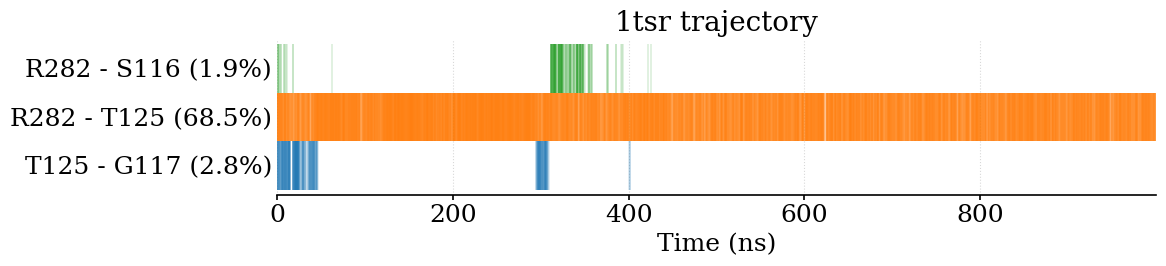

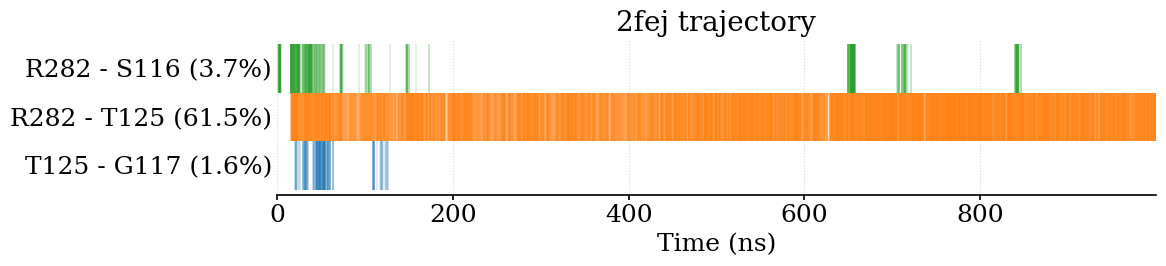

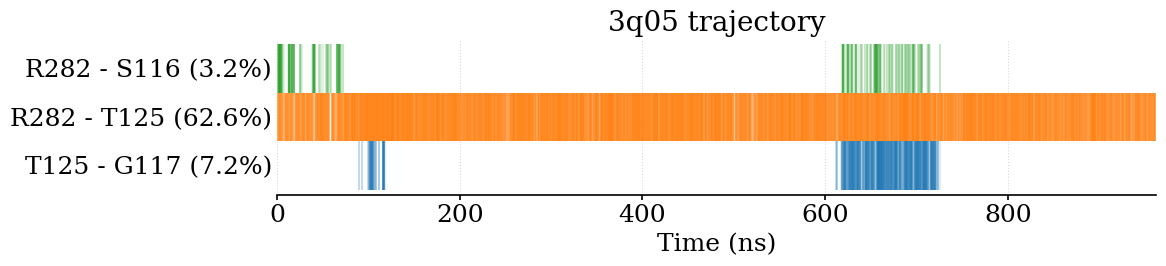

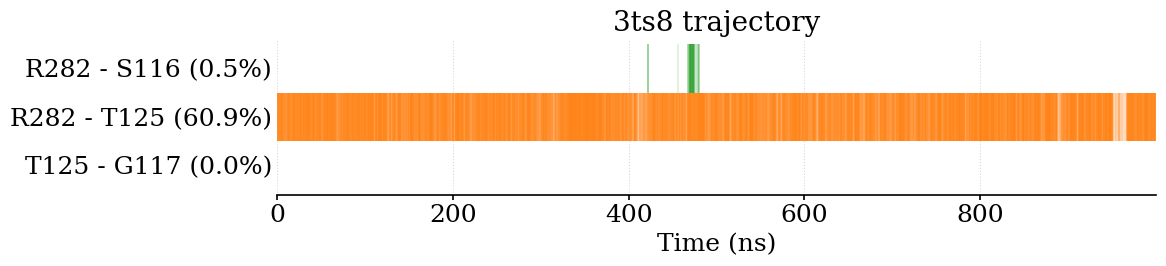

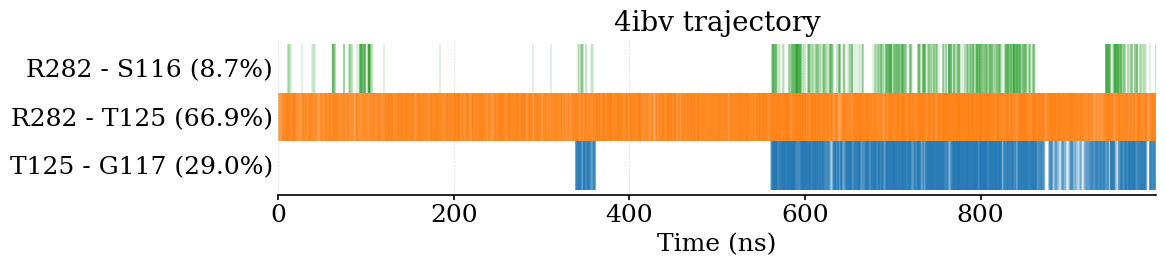

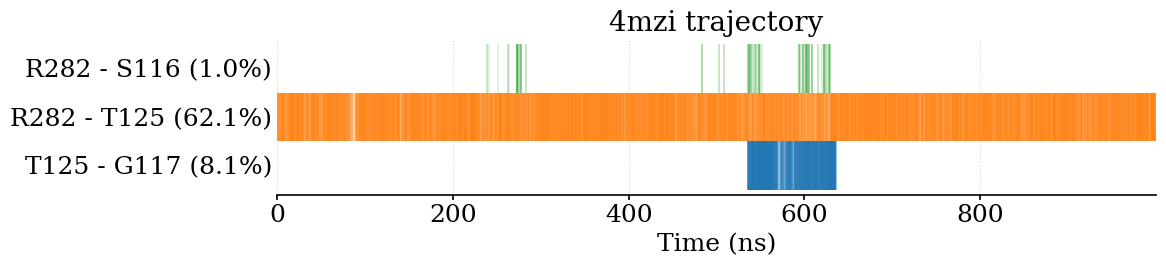

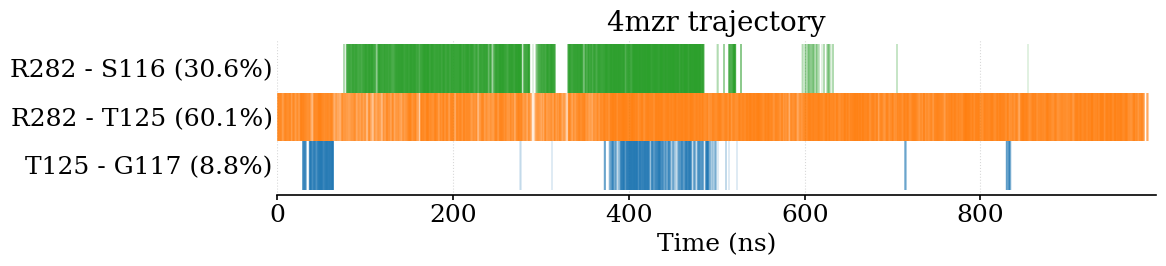

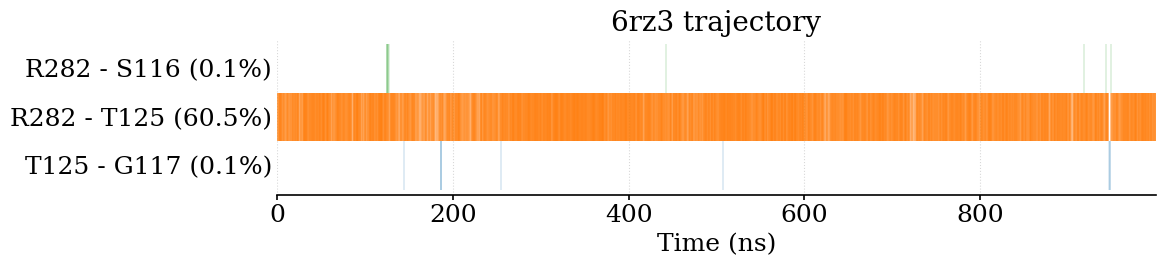

In [16]:
for traj_name, traj_data in results.items():
    hbond_dict = {
        "R282 - S116": traj_data["ARG189-SER23"],
        "R282 - T125": traj_data["ARG189-THR32"],
        "T125 - G117": traj_data["THR32-GLY24"]
    }
    total_frames = traj_data["num_frames"]
    traj_name = traj_name.replace(".pdb", "")
    plot_multibond_barcode_pub(
        hbond_dict=hbond_dict,
        total_frames=total_frames,
        dt=0.1,
        title=f"{traj_name} trajectory",
        font_size=18
    )